In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

In [10]:
train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

In [11]:
test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

In [12]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [13]:
print("Training Documents: ", len(X_train_text))
print("Testing Documents: ", len(X_test_text))
print("Number of Classes: ", len(class_names))

Training Documents:  11314
Testing Documents:  7532
Number of Classes:  20


In [14]:
vectorizer = CountVectorizer(stop_words='english', min_df=2)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [15]:
print(f"Training feature matrix: {X_train.shape}")
print(f"Testing feature matrix: {X_test.shape}")

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [16]:
mnb = MultinomialNB()

mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

In [17]:
binary_vectorizer = CountVectorizer(stop_words='english', min_df=2, binary=True)

X_train_binary = binary_vectorizer.fit_transform(X_train_text)

X_test_binary = binary_vectorizer.transform(X_test_text)

In [18]:
bnb = BernoulliNB()

bnb.fit(X_train_binary, y_train)

y_pred_bnb = bnb.predict(X_test_binary)

In [19]:
def evaluate(model_name, y_true, y_pred):
    print("\n",model_name,"\n")
    
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision :", precision_score(y_true, y_pred, average='weighted'))
    print("Recall :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

In [20]:
evaluate("Multinomial Naive Bayes", y_test, y_pred_mnb)
evaluate("Bernoulli Naive Bayes", y_test, y_pred_bnb)


 Multinomial Naive Bayes 

Accuracy : 0.6510886882634095
Precision : 0.642532222238185
Recall : 0.6510886882634095
F1 Score : 0.6296441343359875

 Bernoulli Naive Bayes 

Accuracy : 0.4851301115241636
Precision : 0.6270343160004399
Recall : 0.4851301115241636
F1 Score : 0.4808387927958853


In [23]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("MNB", mnb, y_pred_mnb),
    ("BNB", bnb, y_pred_bnb)
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred,average='weighted'),
        recall_score(y_test, pred,average='weighted'),
        f1_score(y_test, pred,average='weighted'),
    ]
print(results)   

  Model  Accuracy  Precision    Recall  F1 Score
0   MNB  0.651089   0.642532  0.651089  0.629644
1   BNB  0.485130   0.627034  0.485130  0.480839


(array([0, 1]), [Text(0, 0, 'MNB'), Text(1, 0, 'BNB')])

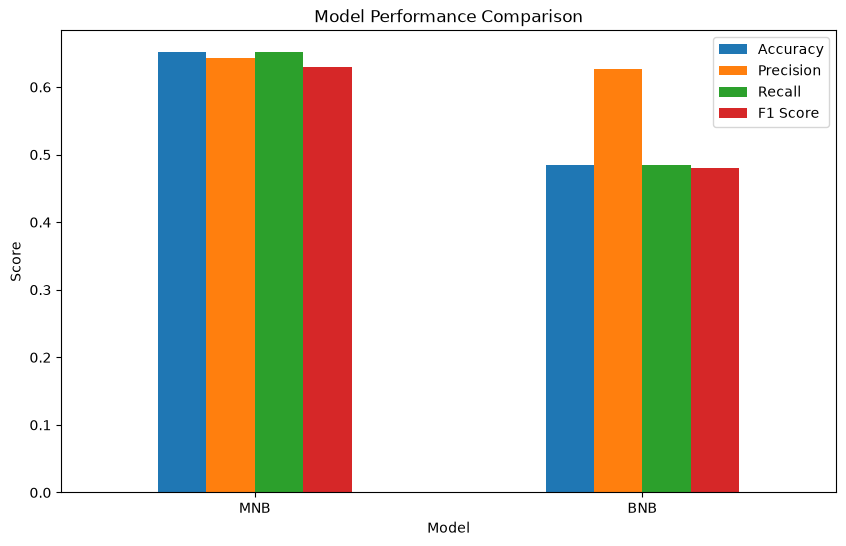

In [ ]:
results.set_index('Model', inplace=True)
results.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)